# Analyse environmentale des ESB aux Etats-Unis

## Dépendances

In [19]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

from sklearn.manifold import TSNE
from sklearn.decomposition import KernelPCA

from scipy.spatial.distance import cdist
from sklearn.mixture import GaussianMixture
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

## Chargement des données

In [20]:
RAW_FILE = "../data/ESB_adoption_dataset_v8_update_august_2024.xlsx" # I renamed the file so pay attention to modify this line.
SHEET    = "1. District-level data"

MISSING_LOGICAL = {"Not applicable"}                         
MISSING_DATA    = {"Missing value", "Blank cell", "TBD", "N/A", "NA", "", " "}                      

In [21]:
df = (pd.read_excel(RAW_FILE, sheet_name=SHEET)
        .replace(list(MISSING_LOGICAL), "logical_na")
        .replace(list(MISSING_DATA), np.nan))

In [22]:
df = df.loc[:, 
            ['0a. Has committed ESBs?',
            '1a. State',
            '1p. Locale broad type (name)',
            '2a. Total number of buses',
            '3a. Number of ESBs committed ',
            '3b. Number of delivered or operating ESBs',
            '3i. Percent of fleet that is electric',
            '3k. Utility/energy company involved 1',
            '3k. Utility/energy company involved 2',
            '3k. Utility/energy company involved 3',
            '5h. Ozone concentration',
            '5l. Average rate of asthma among adults aged 18 and older',
            '5o. EPA 2022 Clean School Bus Rebate Program prioritized school district?',
            '5p. EPA 2023 Clean School Bus Grant & Rebate Programs prioritized school district?',
            '6a. Has any expression of interest in ESBs?',
            '6f. Member of Climate Mayors Electric Vehicle Purchasing Collaborative?',
            '6g. School district sustainability commitment',
            '6h. District contains Generation180 Solar School?']
            ]

In [23]:
df.rename(columns={'1g. State': '1g. State Code'}, inplace=True)

## Traitement des noms de colonnes

In [24]:
df.columns = [col[4:] for col in df.columns]
print(df.columns)

Index(['Has committed ESBs?', 'State', 'Locale broad type (name)',
       'Total number of buses', 'Number of ESBs committed ',
       'Number of delivered or operating ESBs',
       'Percent of fleet that is electric',
       'Utility/energy company involved 1',
       'Utility/energy company involved 2',
       'Utility/energy company involved 3', 'Ozone concentration',
       'Average rate of asthma among adults aged 18 and older',
       'EPA 2022 Clean School Bus Rebate Program prioritized school district?',
       'EPA 2023 Clean School Bus Grant & Rebate Programs prioritized school district?',
       'Has any expression of interest in ESBs?',
       'Member of Climate Mayors Electric Vehicle Purchasing Collaborative?',
       'School district sustainability commitment',
       'District contains Generation180 Solar School?'],
      dtype='object')


In [25]:
# Strip leading and trailing whitespace
df.columns = df.columns.str.strip()
# Replace spaces with underscores and convert to lowercase
df.columns = df.columns.str.replace(' ', '_').str.lower()

In [26]:
print(df.columns)

Index(['has_committed_esbs?', 'state', 'locale_broad_type_(name)',
       'total_number_of_buses', 'number_of_esbs_committed',
       'number_of_delivered_or_operating_esbs',
       'percent_of_fleet_that_is_electric',
       'utility/energy_company_involved_1',
       'utility/energy_company_involved_2',
       'utility/energy_company_involved_3', 'ozone_concentration',
       'average_rate_of_asthma_among_adults_aged_18_and_older',
       'epa_2022_clean_school_bus_rebate_program_prioritized_school_district?',
       'epa_2023_clean_school_bus_grant_&_rebate_programs_prioritized_school_district?',
       'has_any_expression_of_interest_in_esbs?',
       'member_of_climate_mayors_electric_vehicle_purchasing_collaborative?',
       'school_district_sustainability_commitment',
       'district_contains_generation180_solar_school?'],
      dtype='object')


## Gestions des valeurs manquantes

In [27]:
df.isna().sum()

has_committed_esbs?                                                                   0
state                                                                                 0
locale_broad_type_(name)                                                              0
total_number_of_buses                                                              9786
number_of_esbs_committed                                                              0
number_of_delivered_or_operating_esbs                                                 0
percent_of_fleet_that_is_electric                                                   304
utility/energy_company_involved_1                                                 19379
utility/energy_company_involved_2                                                 19499
utility/energy_company_involved_3                                                 19513
ozone_concentration                                                                6324
average_rate_of_asthma_among_adu

Nous pouvons voir que certaines variables ont beaucoup de valeurs manquantes. Ces variables ont une grande importance dans notre analyse, mais elles sont inutilisables car elles risquent de biaiser les résultats. Nous devons donc les supprimer.

De plus la variable has_any_expression_of_interest_in_esbs? n'a que peu de valeurs manquantes. Nous pouvons donc retirer les valeurs manquantes de cette variable.

In [28]:
df.drop(columns=['utility/energy_company_involved_1', 
               'utility/energy_company_involved_2', 
               'utility/energy_company_involved_3',
               'member_of_climate_mayors_electric_vehicle_purchasing_collaborative?',
               'school_district_sustainability_commitment',
               'district_contains_generation180_solar_school?'], inplace=True)

In [29]:
df.dropna(subset=['has_any_expression_of_interest_in_esbs?'], inplace=True)

In [30]:
df.isna().sum()

has_committed_esbs?                                                                  0
state                                                                                0
locale_broad_type_(name)                                                             0
total_number_of_buses                                                             9763
number_of_esbs_committed                                                             0
number_of_delivered_or_operating_esbs                                                0
percent_of_fleet_that_is_electric                                                  304
ozone_concentration                                                               6301
average_rate_of_asthma_among_adults_aged_18_and_older                             6427
epa_2022_clean_school_bus_rebate_program_prioritized_school_district?                0
epa_2023_clean_school_bus_grant_&_rebate_programs_prioritized_school_district?       0
has_any_expression_of_interest_in_esbs?    

Intéressons nous maintenant aux colonnes 'total_number_of_buses', 'percent_of_fleet_that_is_electric', 'ozone_concentration' et 'average_rate_of_asthma_among_adults_aged_18_and_older'.

In [31]:
# Creating a new DataFrame for inference on the columns : 
# 'total_number_of_buses', 'percent_of_fleet_that_is_electric', 'ozone_concentration' et 'average_rate_of_asthma_among_adults_aged_18_and_older'

df_inference = df[['state', 'total_number_of_buses', 'percent_of_fleet_that_is_electric', 'ozone_concentration', 'average_rate_of_asthma_among_adults_aged_18_and_older']]

In [32]:
df.groupby('state').agg({
    'total_number_of_buses': 'sum',
    'percent_of_fleet_that_is_electric': 'mean',
    'ozone_concentration': 'mean',
    'average_rate_of_asthma_among_adults_aged_18_and_older': 'mean'
}).reset_index()

,state,total_number_of_buses,percent_of_fleet_that_is_electric,ozone_concentration,average_rate_of_asthma_among_adults_aged_18_and_older
0,ALABAMA,10482.0,0.018629,59.936924,0.101614
1,ALASKA,954.0,0.008025,0.000000,0.096654
2,AMERICAN SAMOA,0.0,NaN,NaN,0.000000
3,ARIZONA,6641.0,0.018426,62.990424,0.101918
4,ARKANSAS,7016.0,0.006159,57.290641,0.099566
5,CALIFORNIA,18083.0,0.042831,63.445950,0.090595
6,COLORADO,1020.0,0.000695,60.897479,0.090859
7,CONNECTICUT,587.0,0.000165,67.878371,0.094106
8,DELAWARE,1551.0,0.000811,62.495685,0.103048
9,DISTRICT OF COLUMBIA,683.0,0.001031,64.810775,0.112329


Pour les lignes n'ayant pas de valeurs pour les nombres de bus nous pouvons supposer qu'il n'y en a aucun. Le pourcentage de bus électriques peut être considéré comme 0% si le nombre de bus est 0, sinon nous pouvons les remplacer par la médiane de la colonne. Pour les concentrations d'ozone et les taux d'asthme, nous pouvons remplacer les valeurs manquantes par la médiane de la colonne.

In [33]:
df.fillna({
    'total_number_of_buses': 0.0,
    'percent_of_fleet_that_is_electric': df['percent_of_fleet_that_is_electric'].median() if df['percent_of_fleet_that_is_electric'].notna().any() else 0.0,
    'ozone_concentration': df['ozone_concentration'].median(),
    'average_rate_of_asthma_among_adults_aged_18_and_older': df['average_rate_of_asthma_among_adults_aged_18_and_older'].median()
}, inplace=True)

In [34]:
df.groupby('state').agg({
    'total_number_of_buses': 'sum',
    'percent_of_fleet_that_is_electric': 'mean',
    'ozone_concentration': 'mean',
    'average_rate_of_asthma_among_adults_aged_18_and_older': 'mean'
}).reset_index()

,state,total_number_of_buses,percent_of_fleet_that_is_electric,ozone_concentration,average_rate_of_asthma_among_adults_aged_18_and_older
0,ALABAMA,10482.0,0.018629,59.848216,0.101158
1,ALASKA,954.0,0.008025,1.095706,0.096673
2,AMERICAN SAMOA,0.0,0.000000,59.168126,0.000000
3,ARIZONA,6641.0,0.018326,60.271309,0.098891
4,ARKANSAS,7016.0,0.006159,57.703688,0.099148
5,CALIFORNIA,18083.0,0.041885,61.052860,0.094549
6,COLORADO,1020.0,0.000639,60.295689,0.093227
7,CONNECTICUT,587.0,0.000158,66.020736,0.094865
8,DELAWARE,1551.0,0.000793,60.325538,0.099536
9,DISTRICT OF COLUMBIA,683.0,0.001031,59.247600,0.097869


In [35]:
df.isna().sum()

has_committed_esbs?                                                               0
state                                                                             0
locale_broad_type_(name)                                                          0
total_number_of_buses                                                             0
number_of_esbs_committed                                                          0
number_of_delivered_or_operating_esbs                                             0
percent_of_fleet_that_is_electric                                                 0
ozone_concentration                                                               0
average_rate_of_asthma_among_adults_aged_18_and_older                             0
epa_2022_clean_school_bus_rebate_program_prioritized_school_district?             0
epa_2023_clean_school_bus_grant_&_rebate_programs_prioritized_school_district?    0
has_any_expression_of_interest_in_esbs?                                     

## Matrice de corrélation

In [36]:
df_num = df.select_dtypes(include=[np.number])

In [37]:
df_num.info()

<class 'pandas.core.frame.DataFrame'>
Index: 19493 entries, 0 to 19515
Data columns (total 7 columns):
 #   Column                                                 Non-Null Count  Dtype  
---  ------                                                 --------------  -----  
 0   total_number_of_buses                                  19493 non-null  float64
 1   number_of_esbs_committed                               19493 non-null  int64  
 2   number_of_delivered_or_operating_esbs                  19493 non-null  int64  
 3   percent_of_fleet_that_is_electric                      19493 non-null  float64
 4   ozone_concentration                                    19493 non-null  float64
 5   average_rate_of_asthma_among_adults_aged_18_and_older  19493 non-null  float64
 6   has_any_expression_of_interest_in_esbs?                19493 non-null  float64
dtypes: float64(5), int64(2)
memory usage: 1.2 MB


Text(0.5, 1.0, 'Correlation Heatmap of Numerical Features')

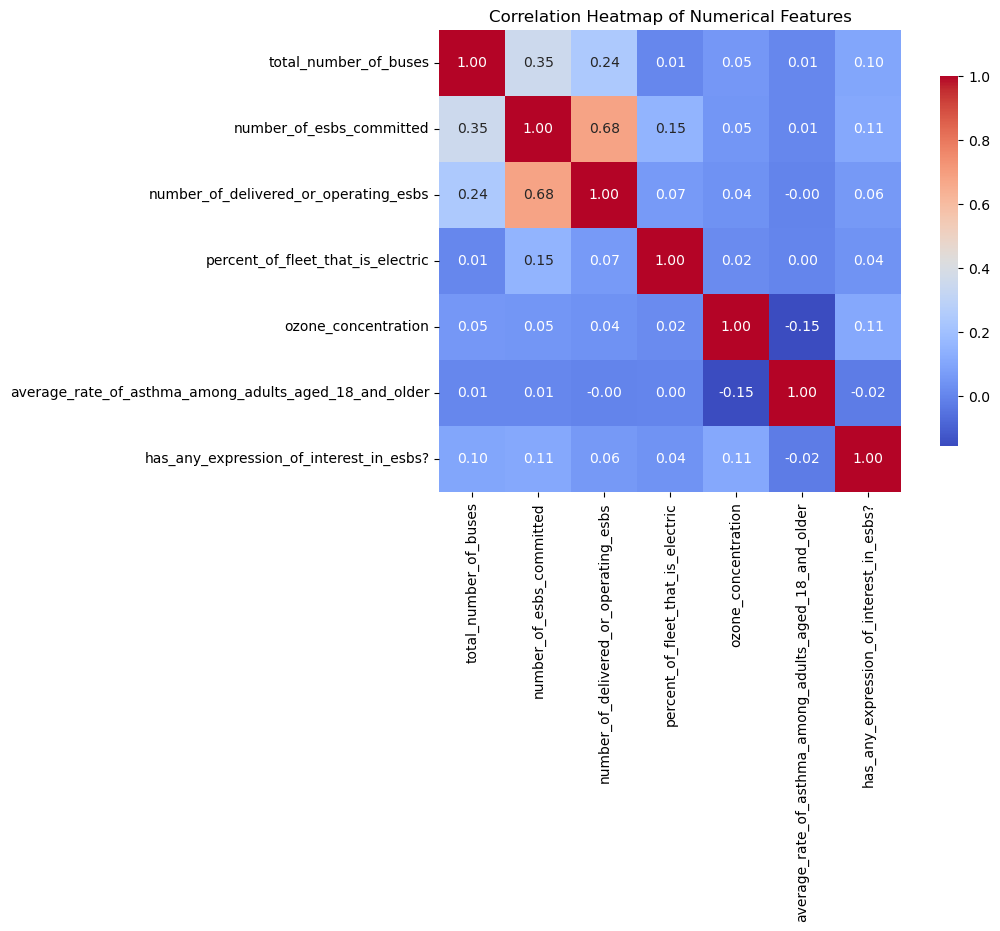

In [38]:
plt.figure(figsize=(10, 6))
sns.heatmap(df_num.corr(), annot=True, fmt=".2f", cmap='coolwarm', square=True, cbar_kws={"shrink": .8})
plt.title('Correlation Heatmap of Numerical Features')

On peut voir grâce à la matrice de corrélation que les variables 'number_of_esb_committed' et 'number_of_delivered_or_operating_esbs' sont très corrélées. Cela est logique car le nombre d'ESB livrés ou en fonctionnement est une partie du nombre total d'ESB engagés. Nous allons donc supprimer la variable 'number_of_esb_committed'.

In [39]:
df.drop(columns=['number_of_esbs_committed'], inplace=True)

df_num = df.select_dtypes(include=[np.number])

Text(0.5, 1.0, 'Correlation Heatmap of Numerical Features')

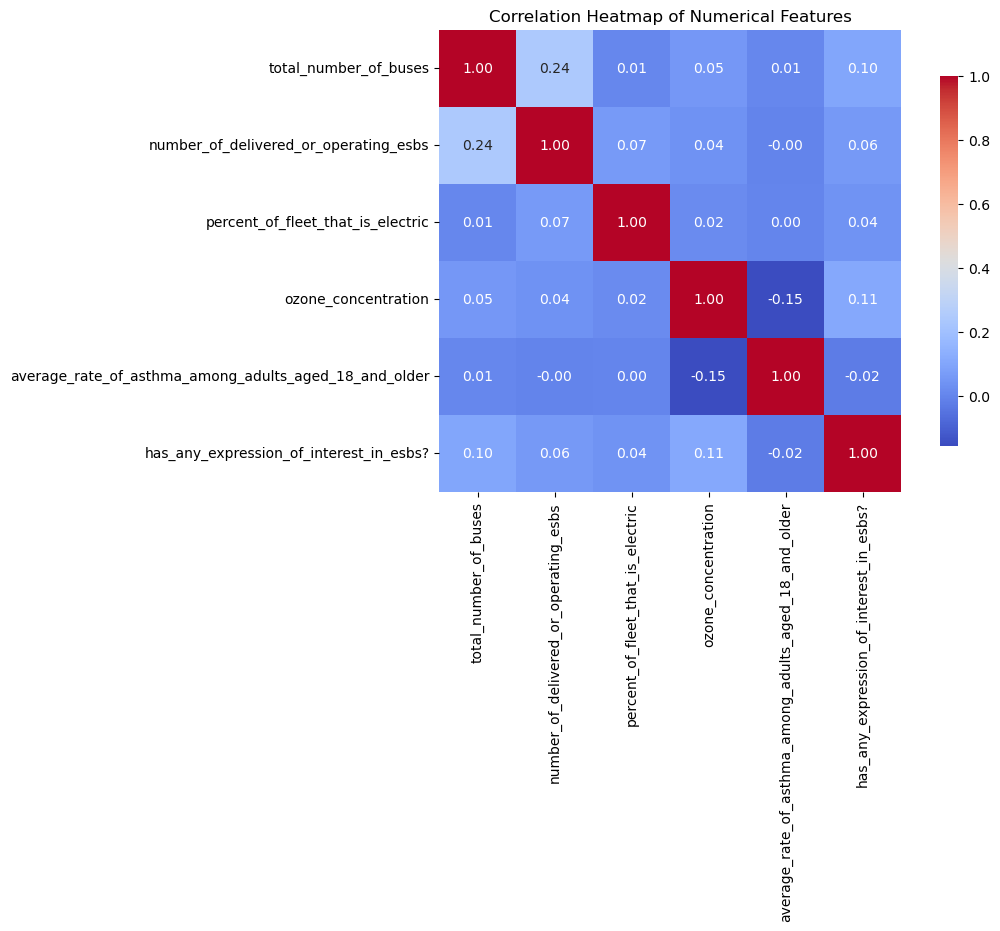

In [40]:
plt.figure(figsize=(10, 6))
sns.heatmap(df_num.corr(), annot=True, fmt=".2f", cmap='coolwarm', square=True, cbar_kws={"shrink": .8})
plt.title('Correlation Heatmap of Numerical Features')

In [41]:
X = df_num
X_features = X.columns

## Standardisation des variables

Puisque dans les algorithmes / modèles de clustering, la distance a un rôle important, on standardise les variables pour que des variables n'aient pas plus d'influence que d'autres lors du calcul des distances.

In [42]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [43]:
df_scaled = pd.DataFrame(X_scaled, columns=X_features)
df_scaled.head()

,total_number_of_buses,number_of_delivered_or_operating_esbs,percent_of_fleet_that_is_electric,ozone_concentration,average_rate_of_asthma_among_adults_aged_18_and_older,has_any_expression_of_interest_in_esbs?
0,-0.193070,-0.070017,-0.075209,0.007936,0.181659,-0.678343
1,0.922838,-0.070017,-0.075209,0.286330,0.281796,-0.678343
2,1.690024,-0.070017,-0.075209,1.391631,-0.418947,-0.678343
3,0.892947,-0.070017,-0.075209,0.199548,-0.203394,-0.678343
4,-0.193070,-0.070017,-0.075209,0.007936,0.181659,-0.678343


Le but est de voir si certains états ont des caractéristiques environnementales similaires. Pour cela, il nous faut la colonne 'state' qui contient le nom des états. Nous allons donc l'ajouter à notre dataframe.

In [44]:
df_scaled['state'] = df['state']

In [45]:
df_scaled.head()

,total_number_of_buses,number_of_delivered_or_operating_esbs,percent_of_fleet_that_is_electric,ozone_concentration,average_rate_of_asthma_among_adults_aged_18_and_older,has_any_expression_of_interest_in_esbs?,state
0,-0.193070,-0.070017,-0.075209,0.007936,0.181659,-0.678343,ALABAMA
1,0.922838,-0.070017,-0.075209,0.286330,0.281796,-0.678343,ALABAMA
2,1.690024,-0.070017,-0.075209,1.391631,-0.418947,-0.678343,ALABAMA
3,0.892947,-0.070017,-0.075209,0.199548,-0.203394,-0.678343,ALABAMA
4,-0.193070,-0.070017,-0.075209,0.007936,0.181659,-0.678343,ALABAMA


# Algorithmes de clustering (K-Means, GMM, DBSCAN, Agglomerative Clustering)

Évaluation des résultats :

    Silhouette Score
    Davies-Bouldin Score
    Calinski-Harabasz Score
    Dunn Index

Visualisation : à l’aide de t-SNE ou Kernel PCA projetées en 2D pour mieux interpréter les regroupements visuellement.

Rappel pour les métriques : Le choix du nombre de clusters va être basé sur les résultats des 4 scores (minimiser Davies-Bouldin et maximiser Silhouette, Calinski-Harabasz et Dunn).

Le Dunn Index se calcule comme suit :

$$
Dunn Index = \frac{\min_{i,j} d(C_i, C_j)}{\max_k \delta(C_k)}
$$

In [46]:
def dunn_index(X, labels):
    unique_clusters = np.unique(labels)
    inter_cluster_distances = []
    intra_cluster_diameters = []

    for i in unique_clusters:
        cluster_i = X[labels == i]
        intra_dist = cdist(cluster_i, cluster_i)
        intra_cluster_diameters.append(np.max(intra_dist))

        for j in unique_clusters:
            if i < j:
                cluster_j = X[labels == j]
                inter_dist = cdist(cluster_i, cluster_j)
                inter_cluster_distances.append(np.min(inter_dist))

    return np.min(inter_cluster_distances) / np.max(intra_cluster_diameters)

In [47]:
def compute_scores(X, labels):
    """Fonction pour obtenir un ensemble de scores sur les clusters"""
    if len(np.unique(labels)) < 2:
        return (np.nan, np.nan, np.nan, np.nan)

    silhouette = silhouette_score(X, labels)
    davies = davies_bouldin_score(X, labels)
    calinski = calinski_harabasz_score(X, labels)
    dunn = dunn_index(X, labels)

    return (silhouette, davies, calinski, dunn)

In [48]:
k_values = range(2, 11)

scores_kmeans = {"silhouette": [], "davies": [], "calinski": [], "dunn": []}
scores_gmm = {"silhouette": [], "davies": [], "calinski": [], "dunn": []}
scores_agglo = {"silhouette": [], "davies": [], "calinski": [], "dunn": []}

for k in k_values:
    # KMeans
    km_labels = KMeans(n_clusters=k, random_state=42).fit_predict(X_scaled)
    s, d, c, di = compute_scores(X_scaled, km_labels)
    scores_kmeans["silhouette"].append(s)
    scores_kmeans["davies"].append(d)
    scores_kmeans["calinski"].append(c)
    scores_kmeans["dunn"].append(di)

    # GMM
    gmm_labels = GaussianMixture(n_components=k, random_state=42).fit(X_scaled).predict(X_scaled)
    s, d, c, di = compute_scores(X_scaled, gmm_labels)
    scores_gmm["silhouette"].append(s)
    scores_gmm["davies"].append(d)
    scores_gmm["calinski"].append(c)
    scores_gmm["dunn"].append(di)

    # Agglomerative
    agg_labels = AgglomerativeClustering(n_clusters=k).fit_predict(X_scaled)
    s, d, c, di = compute_scores(X_scaled, agg_labels)
    scores_agglo["silhouette"].append(s)
    scores_agglo["davies"].append(d)
    scores_agglo["calinski"].append(c)
    scores_agglo["dunn"].append(di)

In [49]:
def plot_clustering_scores(k_values, scores_dicts, algo_names):
    metrics = ["silhouette", "davies", "calinski", "dunn"]
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    axes = axes.flatten()

    for i, metric in enumerate(metrics):
        ax = axes[i]
        for scores, name in zip(scores_dicts, algo_names):
            ax.plot(k_values, scores[metric], marker='o', label=name)
        ax.set_title(metric.capitalize())
        ax.set_xlabel("Nombre de clusters (k)")
        ax.set_ylabel("Score")
        ax.legend()
        ax.grid(True)

    plt.suptitle("Comparaison des algorithmes de clustering", fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

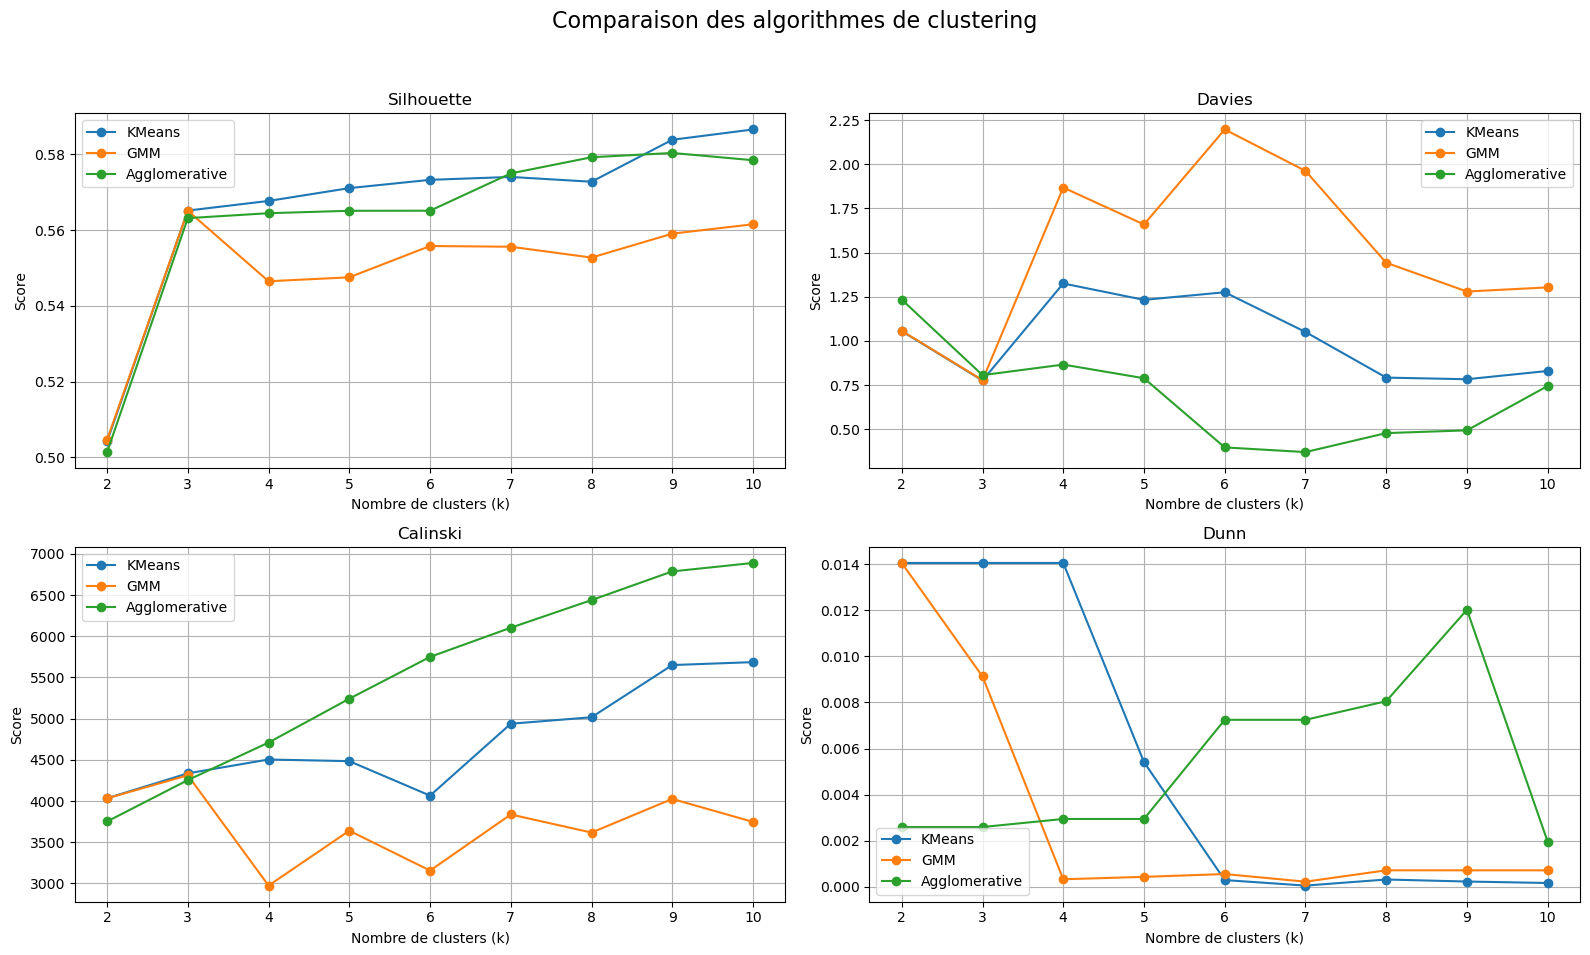

In [50]:
plot_clustering_scores(
    k_values,
    [scores_kmeans, scores_gmm, scores_agglo],
    ["KMeans", "GMM", "Agglomerative"]
)

Pour chaque méthode le nombre approprié de clusters semble être :

| Méthode de Clustering | Nombre de Clusters |
|-|-|
| KMeans                     | 4                  |
| AgglomerativeClustering    | 9                  |
| GMM                        | 2                  |